# Part 2D — Final Evaluation: All Models Compared
**Unit:** CIS143-6 Applications of AI  
> Run after all previous notebooks. Loads all saved models from Google Drive.
> Produces: comparison table, precision-recall curves, confusion matrices, bar chart, error analysis.

## 0. Setup & Load All Models

In [2]:
import os, random, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.convnext import preprocess_input as convnext_preprocess
from tensorflow.keras.applications import ConvNeXtSmall
from scipy.stats import wilcoxon

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = Path('/content/drive/MyDrive/brain_tumour_mri')
DATA_DIR = Path('/content/brain_tumour_data')

if not DATA_DIR.exists():
    shutil.copytree(DRIVE_DIR / 'dataset', DATA_DIR)

TRAIN_DIR = DATA_DIR / 'Training'
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

Mounted at /content/drive


In [4]:
records = []
for cls in CLASSES:
    for img_path in (TRAIN_DIR / cls).glob('*.jpg'):
        records.append({'filepath': str(img_path), 'label': cls})

df = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

# Standard test generator
val_test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = val_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

CLASS_NAMES = list(test_gen.class_indices.keys())
y_true = test_gen.classes
y_true_bin = label_binarize(y_true, classes=list(range(4)))

# Segmented test generator (for CNN Exp B)
def otsu_rescale(img_array):
    img = img_array / 255.0
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        clean_mask = np.zeros_like(mask)
        cv2.drawContours(clean_mask, [largest], -1, 255, -1)
        mask = clean_mask
    return img * np.stack([mask / 255.0] * 3, axis=-1).astype(np.float32)

seg_test_datagen = ImageDataGenerator(preprocessing_function=otsu_rescale)
seg_test_gen = seg_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

effnet_test_datagen = ImageDataGenerator(preprocessing_function=effnet_preprocess)
effnet_test_gen = effnet_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

print(f'Test set: {len(test_df)} images  |  Classes: {CLASS_NAMES}')
# ConvNeXt test generator
convnext_test_datagen = ImageDataGenerator(preprocessing_function=convnext_preprocess)
convnext_test_gen = convnext_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=16, class_mode='categorical', shuffle=False)


Found 840 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Test set: 840 images  |  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
model_files = {
    'Baseline CNN':          'baseline_cnn.keras',
    'ANN':                   'ann_model.keras',
    'CNN Exp A':             'cnn_expA_best.keras',
    'CNN Exp B (Otsu)':      'cnn_expB_best.keras',
    'EfficientNetB0 Exp A':  'effnet_frozen.keras',
    'EfficientNetB0 Exp B':  'effnet_finetuned.keras',
    'ConvNeXtSmall Exp A':   'convnext_frozen.keras',
    'ConvNeXtSmall Exp B':   'convnext_finetuned.keras',
}

models_loaded = {}
for name, fname in model_files.items():
    path = DRIVE_DIR / fname
    if path.exists():
        models_loaded[name] = tf.keras.models.load_model(str(path))
        print(f'Loaded: {name}')
    else:
        print(f'MISSING: {name} ({path})')

Loaded: Baseline CNN
Loaded: ANN
Loaded: CNN Exp A
Loaded: CNN Exp B (Otsu)
Loaded: EfficientNetB0 Exp A
Loaded: EfficientNetB0 Exp B


In [6]:
# Collect predictions for all models
all_probs = {}
all_preds = {}

for name, model in models_loaded.items():
  if 'Otsu' in name:
    gen = seg_test_gen
  elif 'EfficientNet' in name:
    gen = effnet_test_gen
  elif 'ConvNeXt' in name:
    gen = convnext_test_gen
  else:
    gen = test_gen
  gen.reset()
  probs = model.predict(gen, verbose=0)
  all_probs[name] = probs
  all_preds[name] = np.argmax(probs, axis=1)

print('Predictions collected for all models.')

Predictions collected for all models.


## 1. Final Comparison Table

In [7]:
results = {}
for name, preds in all_preds.items():
    true = y_true  # all models evaluated on same test set
    rep = classification_report(true, preds, output_dict=True)
    if 'Otsu' in name:
      gen = seg_test_gen
    elif 'EfficientNet' in name:
      gen = effnet_test_gen
    elif 'ConvNeXt' in name:
      gen = convnext_test_gen
    else:
      gen = test_gen
    gen.reset()

    loss, acc = models_loaded[name].evaluate(gen, verbose=0)
    results[name] = {
        'Accuracy':       round(acc, 4),
        'Macro Precision':round(rep['macro avg']['precision'], 4),
        'Macro Recall':   round(rep['macro avg']['recall'], 4),
        'Macro F1':       round(rep['macro avg']['f1-score'], 4),
    }

results_df = pd.DataFrame(results).T
print('=== FINAL MODEL COMPARISON ===')
print(results_df.to_string())
results_df.style.highlight_max(color='lightgreen', axis=0)

=== FINAL MODEL COMPARISON ===
                      Accuracy  Macro Precision  Macro Recall  Macro F1
Baseline CNN            0.8595           0.8715        0.8595    0.8552
ANN                     0.6000           0.6464        0.6000    0.5538
CNN Exp A               0.8952           0.8980        0.8952    0.8957
CNN Exp B (Otsu)        0.8940           0.9098        0.8940    0.8963
EfficientNetB0 Exp A    0.9381           0.9383        0.9381    0.9373
EfficientNetB0 Exp B    0.9345           0.9349        0.9345    0.9337


,Accuracy,Macro Precision,Macro Recall,Macro F1
Baseline CNN,0.859500,0.871500,0.859500,0.855200
ANN,0.600000,0.646400,0.600000,0.553800
CNN Exp A,0.895200,0.898000,0.895200,0.895700
CNN Exp B (Otsu),0.894000,0.909800,0.894000,0.896300
EfficientNetB0 Exp A,0.938100,0.938300,0.938100,0.937300
EfficientNetB0 Exp B,0.934500,0.934900,0.934500,0.933700


## 2. Precision-Recall Curves — All Models

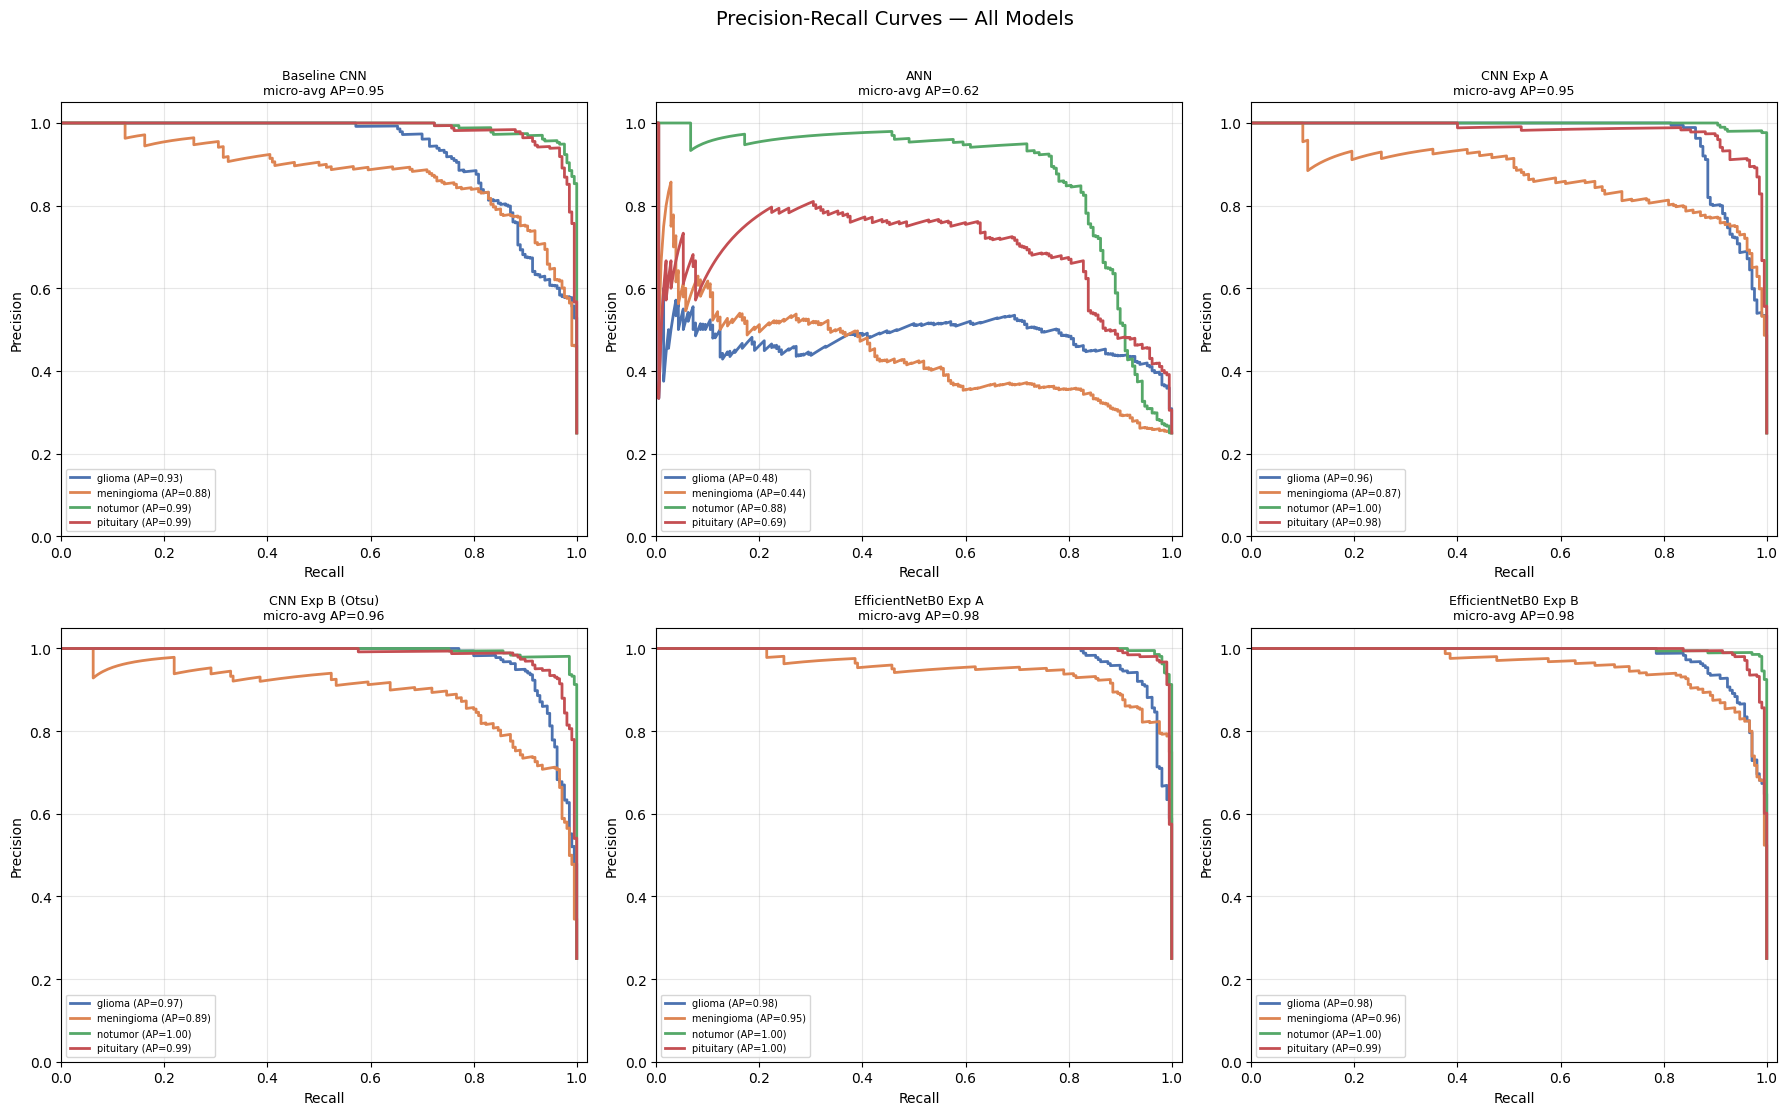

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
colours_cls = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (model_name, probs) in zip(axes.flat, all_probs.items()):
    micro_ap_vals = []
    for i, cls in enumerate(CLASS_NAMES):
        p, r, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
        ap = average_precision_score(y_true_bin[:, i], probs[:, i])
        micro_ap_vals.append(ap)
        ax.plot(r, p, label=f'{cls} (AP={ap:.2f})', color=colours_cls[i], lw=2)
    ax.set_title(f'{model_name}\nmicro-avg AP={np.mean(micro_ap_vals):.2f}', fontsize=9)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.05)

plt.suptitle('Precision-Recall Curves — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Side-by-Side Confusion Matrices

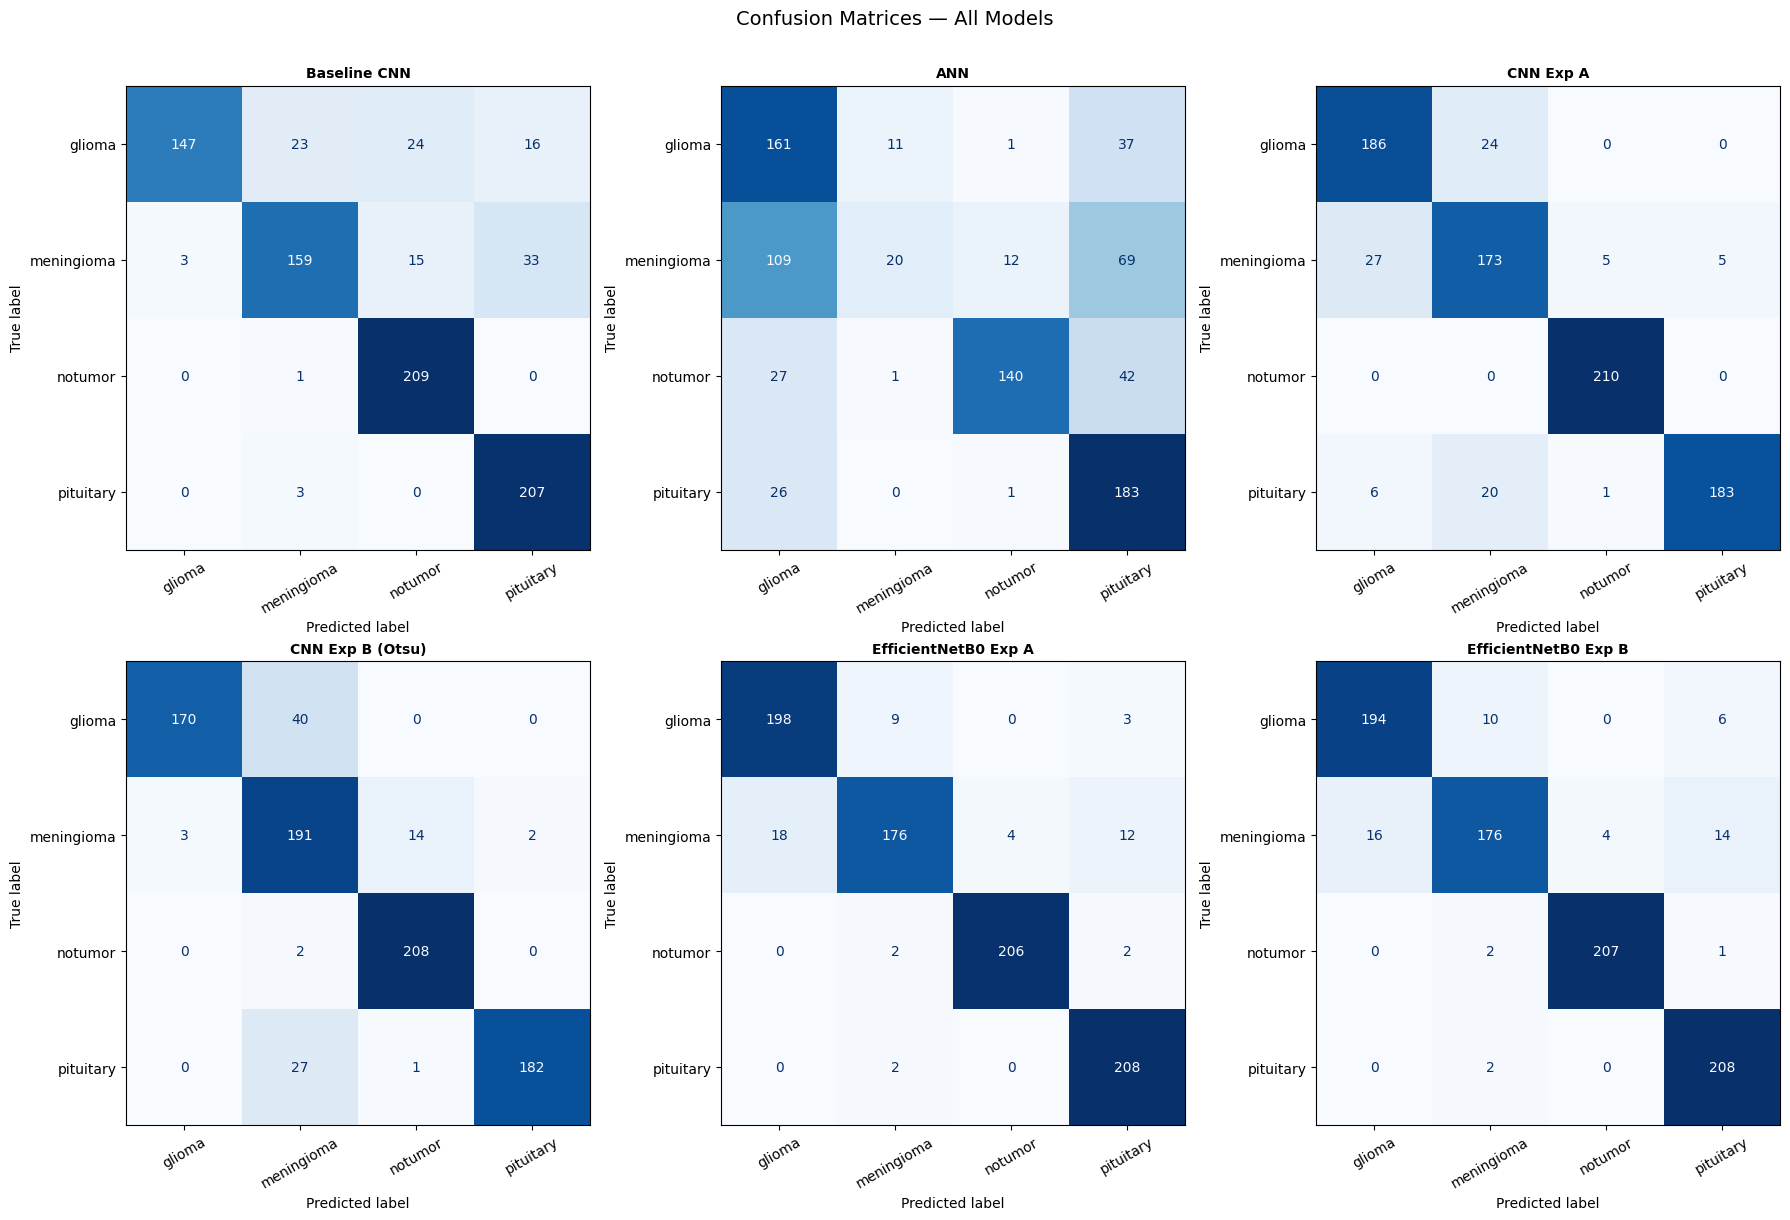

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, (model_name, preds) in zip(axes.flat, all_preds.items()):
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(model_name, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

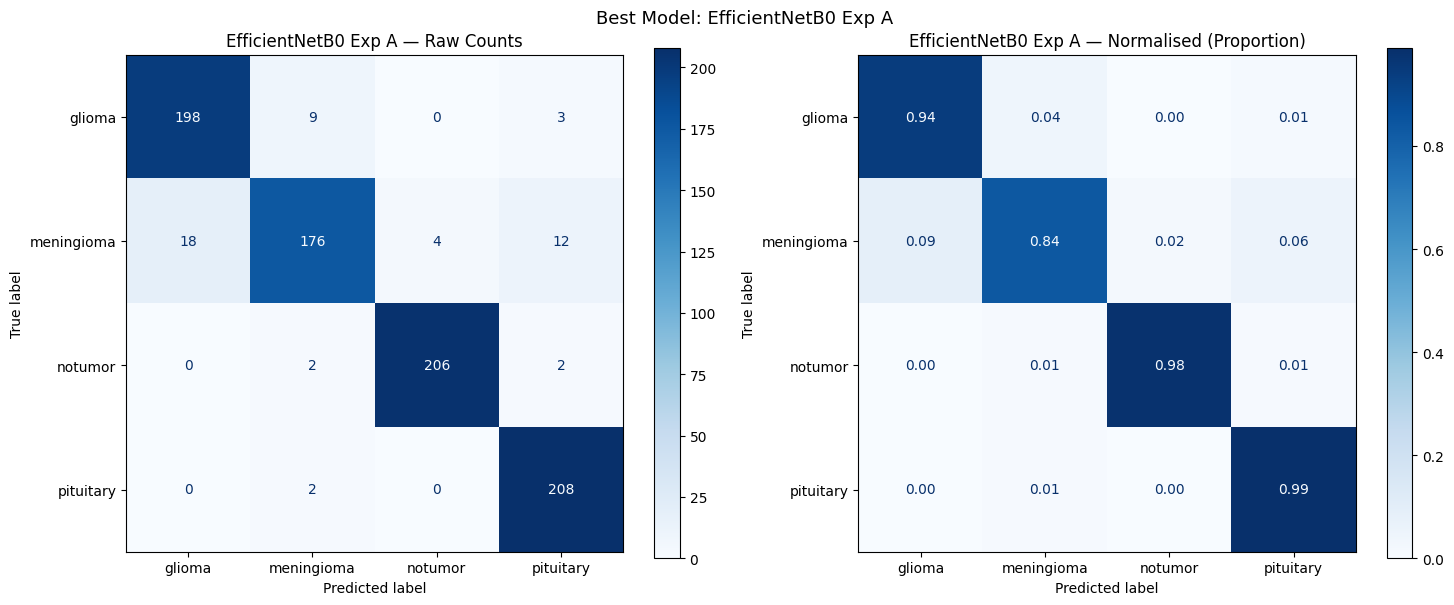

In [10]:
# Normalised confusion matrix for best model
best_name = results_df['Macro F1'].idxmax()
best_preds = all_preds[best_name]
cm_best = confusion_matrix(y_true, best_preds)
cm_norm = cm_best.astype(float) / cm_best.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ConfusionMatrixDisplay(cm_best, display_labels=CLASS_NAMES).plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title(f'{best_name} — Raw Counts')

ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES).plot(ax=ax2, cmap='Blues', values_format='.2f')
ax2.set_title(f'{best_name} — Normalised (Proportion)')

plt.suptitle(f'Best Model: {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Error Analysis — Best Model

In [11]:
from PIL import Image as PILImage

best_gen = (seg_test_gen if 'Otsu' in best_name
            else effnet_test_gen if 'EfficientNet' in best_name
            else convnext_test_gen if 'ConvNeXt' in best_name
            else test_gen)
best_gen.reset()
best_probs = all_probs[best_name]
best_preds_arr = all_preds[best_name]
filepaths = best_gen.filepaths

misclassified = [
    (filepaths[i], y_true[i], best_preds_arr[i], best_probs[i].max())
    for i in range(len(y_true))
    if y_true[i] != best_preds_arr[i]
]
print(f'Misclassified by {best_name}: {len(misclassified)} / {len(y_true)} '
      f'({len(misclassified)/len(y_true)*100:.1f}%)')

# Confusion pair frequency
pair_counts = {}
for _, t, p, _ in misclassified:
    key = f'{CLASS_NAMES[t]} → {CLASS_NAMES[p]}'
    pair_counts[key] = pair_counts.get(key, 0) + 1
print('\nMost common confusion pairs:')
for pair, cnt in sorted(pair_counts.items(), key=lambda x: -x[1])[:8]:
    print(f'  {pair}: {cnt}')

Misclassified by EfficientNetB0 Exp A: 52 / 840 (6.2%)

Most common confusion pairs:
  meningioma → glioma: 18
  meningioma → pituitary: 12
  glioma → meningioma: 9
  meningioma → notumor: 4
  glioma → pituitary: 3
  pituitary → meningioma: 2
  notumor → meningioma: 2
  notumor → pituitary: 2


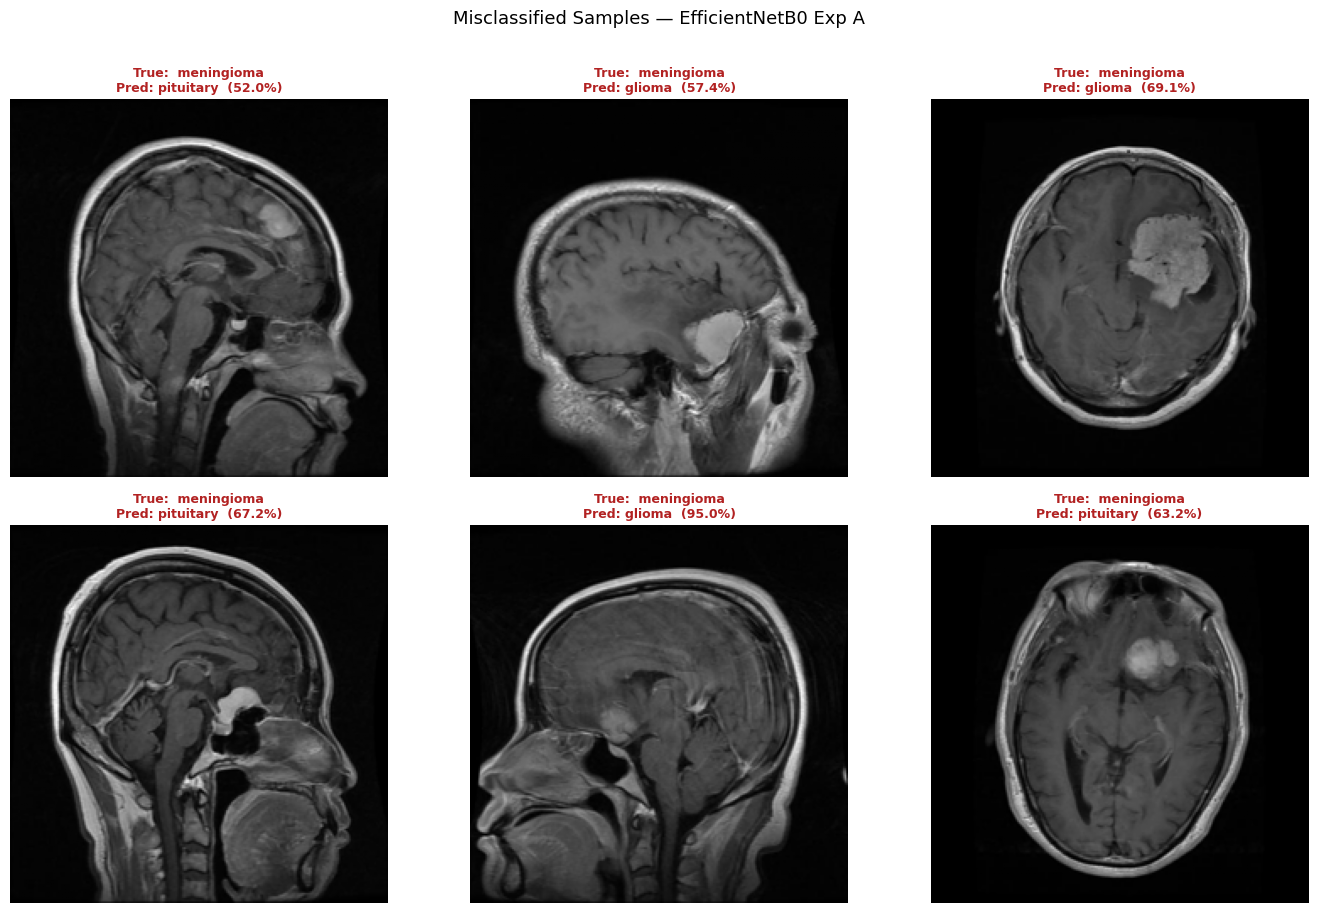

In [12]:
samples = random.sample(misclassified, min(6, len(misclassified)))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (path, true_idx, pred_idx, conf) in zip(axes.flat, samples):
    img = PILImage.open(path).resize((224, 224))
    ax.imshow(img, cmap='gray')
    ax.set_title(
        f'True:  {CLASS_NAMES[true_idx]}\nPred: {CLASS_NAMES[pred_idx]}  ({conf:.1%})',
        fontsize=9, color='firebrick', fontweight='bold'
    )
    ax.axis('off')

plt.suptitle(f'Misclassified Samples — {best_name}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Macro F1 Comparison Bar Chart

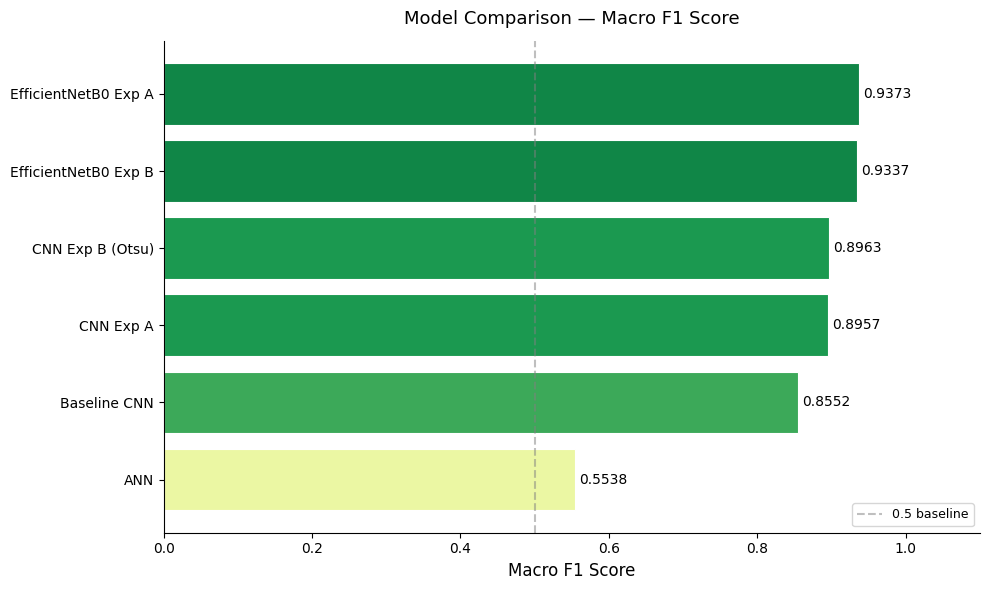


Best model: EfficientNetB0 Exp A
Best Macro F1: 0.9373
Best Accuracy: 0.9381


In [13]:
sorted_df = results_df.sort_values('Macro F1')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sorted_df.index, sorted_df['Macro F1'],
               color=plt.cm.RdYlGn(sorted_df['Macro F1'].values),
               edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
ax.set_xlim(0, 1.1)
ax.set_xlabel('Macro F1 Score', fontsize=12)
ax.set_title('Model Comparison — Macro F1 Score', fontsize=13, pad=12)
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5 baseline')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

print(f'\nBest model: {best_name}')
print(f'Best Macro F1: {results_df.loc[best_name, "Macro F1"]}')
print(f'Best Accuracy: {results_df.loc[best_name, "Accuracy"]}')

## 6. Per-Class F1 Heatmap — All Models

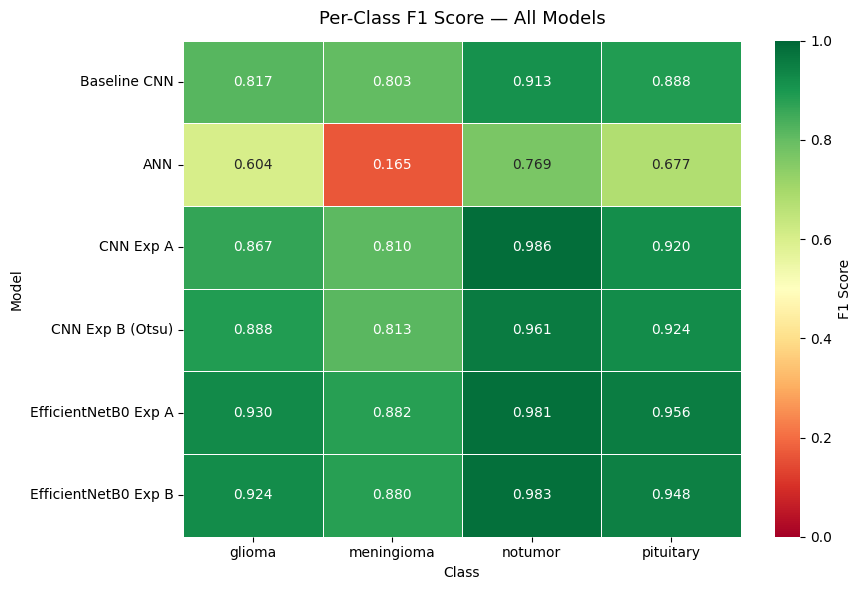

In [14]:
perclass_f1 = {}
for name, preds in all_preds.items():
    rep = classification_report(y_true, preds, target_names=CLASS_NAMES, output_dict=True)
    perclass_f1[name] = {cls: rep[cls]['f1-score'] for cls in CLASS_NAMES}

pc_df = pd.DataFrame(perclass_f1).T
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pc_df, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'F1 Score'})
ax.set_title('Per-Class F1 Score — All Models', fontsize=13, pad=12)
ax.set_xlabel('Class')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

## 7. GradCAM — Model Interpretability (EfficientNetB0 vs Baseline CNN)
GradCAM highlights the image regions that most influenced each prediction.

In [26]:
def make_gradcam_heatmap(img_array, model, pred_index=None):
    img_tensor = tf.cast(img_array, tf.float32)
    sub_models = [l for l in model.layers if isinstance(l, tf.keras.Model)]

    if sub_models:
        base = sub_models[0]
        last_conv = next(
            l.name for l in reversed(base.layers)
            if isinstance(l, tf.keras.layers.Conv2D)
        )
        # Build extractor from base's OWN inputs — avoids cross-graph KeyError
        feat_extractor = tf.keras.models.Model(
            inputs=base.inputs,
            outputs=[base.get_layer(last_conv).output, base.output]
        )
        # Collect layers that sit after the base in the outer model
        post_base, after = [], False
        for layer in model.layers:
            if layer.name == base.name:
                after = True; continue
            if after:
                post_base.append(layer)

        with tf.GradientTape() as tape:
            conv_outputs, x = feat_extractor(img_tensor)
            for layer in post_base:
                x = layer(x)
            predictions = x
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]
    else:
        last_conv = next(
            (l.name for l in reversed(model.layers)
              if isinstance(l, tf.keras.layers.Conv2D)), None
        )
        if last_conv is None:
            raise ValueError("No Conv2D in model — GradCAM not applicable")

        with tf.GradientTape() as tape:
            x = img_tensor
            conv_outputs = None
            for layer in model.layers:
                if layer.name == last_conv:
                    x = layer(x)
                    conv_outputs = x
                    tape.watch(conv_outputs)  # watch before remaining layers run
                else:
                    x = layer(x)
            predictions = x
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), last_conv

def overlay_heatmap(img_rgb, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    return (alpha * heatmap_color + (1 - alpha) * img_rgb).astype(np.uint8)

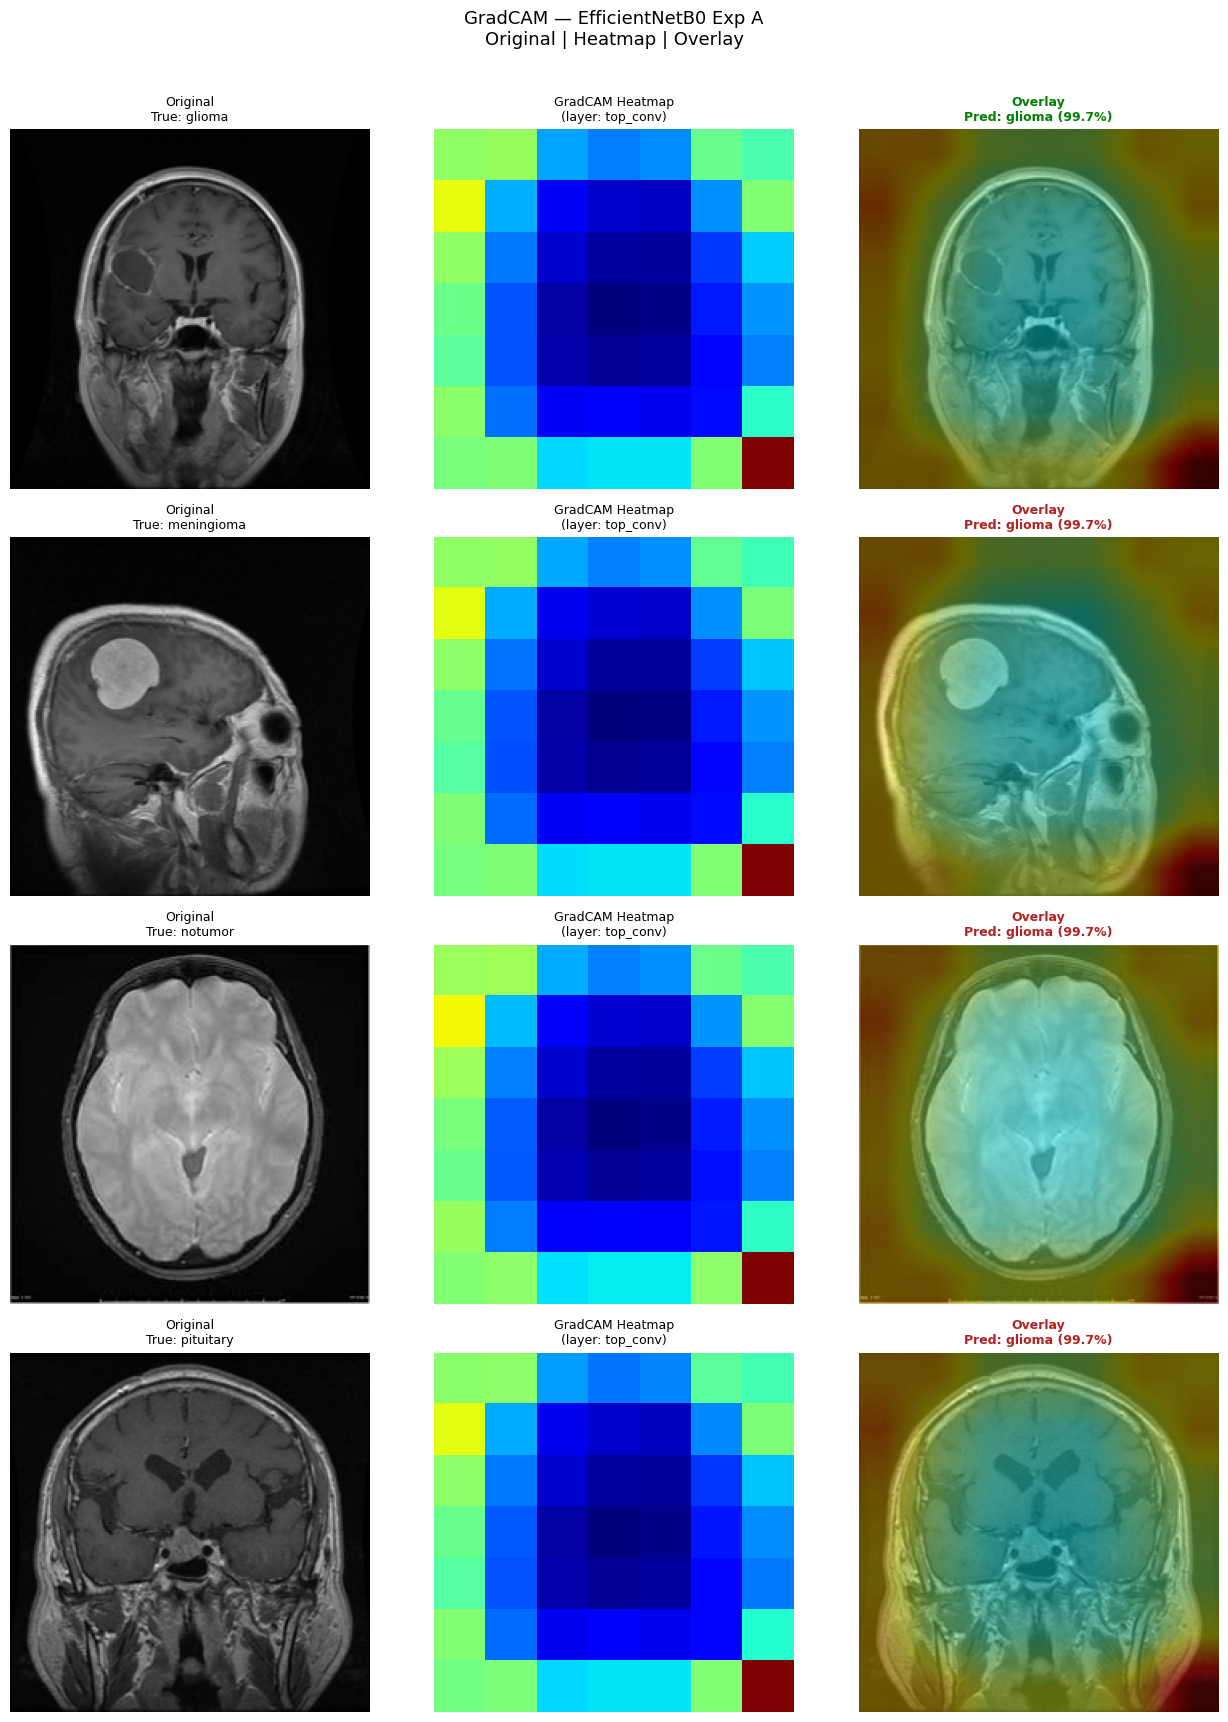

In [27]:
from PIL import Image as PILImage

effnet_model = models_loaded['EfficientNetB0 Exp A']
convnext_model = models_loaded.get('ConvNeXtSmall Exp A')
sample_paths = {}
for i, (path, label) in enumerate(zip(test_gen.filepaths, y_true)):
    cls = CLASS_NAMES[label]
    if cls not in sample_paths:
        sample_paths[cls] = path
    if len(sample_paths) == 4:
        break

fig, axes = plt.subplots(4, 3, figsize=(13, 17))
for row, cls in enumerate(CLASS_NAMES):
    path = sample_paths[cls]
    img = np.array(PILImage.open(path).convert('RGB').resize((224, 224)))
    img_input = img.astype(np.float32) / 255.0
    img_tensor = np.expand_dims(img_input, axis=0)

    probs = effnet_model.predict(img_tensor, verbose=0)
    pred_idx = np.argmax(probs)
    confidence = probs[0][pred_idx]

    heatmap, conv_name = make_gradcam_heatmap(img_tensor, effnet_model)
    overlaid = overlay_heatmap(img, heatmap)

    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'Original\nTrue: {cls}', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(heatmap, cmap='jet')
    axes[row, 1].set_title(f'GradCAM Heatmap\n(layer: {conv_name})', fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlaid)
    axes[row, 2].set_title(
        f'Overlay\nPred: {CLASS_NAMES[pred_idx]} ({confidence:.1%})',
        fontsize=9,
        color='green' if pred_idx == CLASS_NAMES.index(cls) else 'firebrick',
        fontweight='bold'
    )
    axes[row, 2].axis('off')

plt.suptitle('GradCAM — EfficientNetB0 Exp A\nOriginal | Heatmap | Overlay', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

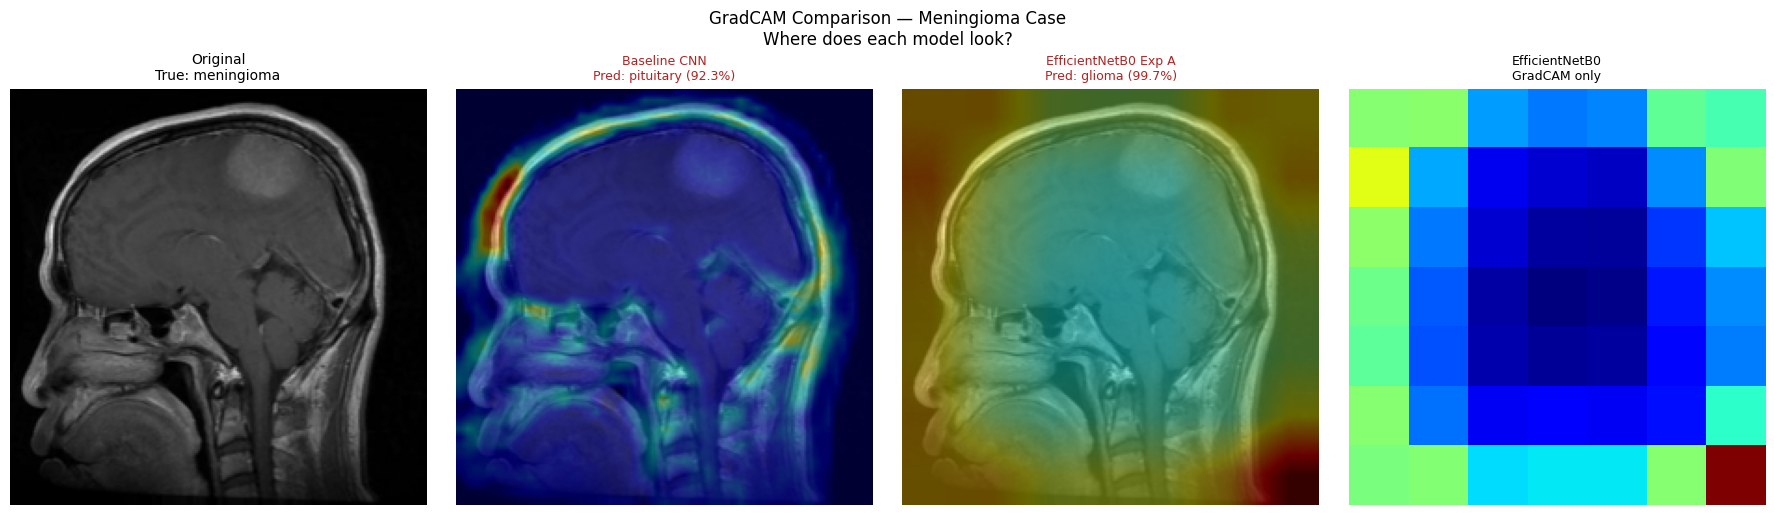

In [28]:
mening_idx = CLASS_NAMES.index('meningioma')
misclassified_mening = [
    (test_gen.filepaths[i], y_true[i], all_preds[best_name][i])
    for i in range(len(y_true))
    if y_true[i] == mening_idx and all_preds['Baseline CNN'][i] != mening_idx
]

if not misclassified_mening:
    # fallback: any meningioma sample
    misclassified_mening = [(test_gen.filepaths[i], y_true[i], all_preds[best_name][i])
                            for i in range(len(y_true)) if y_true[i] == mening_idx]

path, true_idx, pred_idx = misclassified_mening[0]
img = np.array(PILImage.open(path).convert('RGB').resize((224, 224)))
img_input = np.expand_dims(img.astype(np.float32) / 255.0, axis=0)

compare_models = {
    'Baseline CNN': models_loaded['Baseline CNN'],
    'EfficientNetB0 Exp A': models_loaded['EfficientNetB0 Exp A'],
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title(f'Original\nTrue: {CLASS_NAMES[true_idx]}', fontsize=10)
axes[0].axis('off')

for col, (mname, mmodel) in enumerate(compare_models.items(), start=1):
    heatmap, conv_name = make_gradcam_heatmap(img_input, mmodel)
    overlaid = overlay_heatmap(img, heatmap)
    probs = mmodel.predict(img_input, verbose=0)
    pred = np.argmax(probs)
    axes[col].imshow(overlaid)
    axes[col].set_title(
        f'{mname}\nPred: {CLASS_NAMES[pred]} ({probs[0][pred]:.1%})',
        fontsize=9,
        color='green' if pred == true_idx else 'firebrick'
    )
    axes[col].axis('off')

# Heatmap only for EfficientNet
heatmap_eff, _ = make_gradcam_heatmap(img_input, models_loaded['EfficientNetB0 Exp A'])
axes[3].imshow(heatmap_eff, cmap='jet')
axes[3].set_title('EfficientNetB0\nGradCAM only', fontsize=9)
axes[3].axis('off')

plt.suptitle('GradCAM Comparison — Meningioma Case\nWhere does each model look?', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 8. Statistical Significance Testing — Wilcoxon Signed-Rank Test

Point accuracy scores summarise overall performance but mask per-sample behaviour. The **Wilcoxon signed-rank test** (Wilcoxon, 1945) is a non-parametric paired test that compares two models on a sample-by-sample basis — it asks whether one model is *systematically* more correct than the other, across all 840 test images, without assuming a normal error distribution. A p-value < 0.05 indicates the performance difference is statistically significant and unlikely due to chance.

We compare every adjacent model pair in the ranking: Baseline CNN vs best custom CNN, EfficientNetB0 vs ConvNeXtSmall.

In [ ]:
from scipy.stats import wilcoxon

# Per-sample correct/incorrect binary vector for each model
def correct_vector(preds, true): return (preds == true).astype(int)

cv = {name: correct_vector(preds, y_true) for name, preds in all_preds.items()}

# Pairs to compare
pairs = [
    ('Baseline CNN',         'CNN Exp A'),
    ('CNN Exp A',            'EfficientNetB0 Exp A'),
    ('EfficientNetB0 Exp A', 'ConvNeXtSmall Exp A'),
    ('EfficientNetB0 Exp A', 'EfficientNetB0 Exp B'),
    ('ConvNeXtSmall Exp A',  'ConvNeXtSmall Exp B'),
]

print(f"{'Model A':<26} {'Model B':<26} {'Acc A':>7} {'Acc B':>7} {'p-value':>9} {'Significant':>12}")
print('-' * 95)
wilcoxon_results = []
for a, b in pairs:
    if a not in cv or b not in cv: continue
    ca, cb = cv[a], cv[b]
    # Wilcoxon requires at least one non-tie
    diffs = ca.astype(float) - cb.astype(float)
    if np.all(diffs == 0):
        p = 1.0
    else:
        _, p = wilcoxon(ca, cb)
    acc_a = results_df.loc[a, 'Accuracy'] if a in results_df.index else float('nan')
    acc_b = results_df.loc[b, 'Accuracy'] if b in results_df.index else float('nan')
    sig = 'YES ***' if p < 0.001 else ('YES **' if p < 0.01 else ('YES *' if p < 0.05 else 'no'))
    print(f"{a:<26} {b:<26} {acc_a:>7.4f} {acc_b:>7.4f} {p:>9.4f} {sig:>12}")
    wilcoxon_results.append({'Model A': a, 'Model B': b, 'p-value': round(p, 4), 'Significant': p < 0.05})

print('\n* p<0.05  ** p<0.01  *** p<0.001')

## 9. Cost-Sensitive Analysis

Standard accuracy treats all misclassifications equally. In a clinical brain tumour triage context, this is inappropriate: failing to detect a tumour (false negative) carries far greater risk than flagging a healthy scan for further review (false positive). A **cost matrix** assigns differential penalties to each type of error, allowing us to compute a *cost-weighted score* that reflects the real-world impact of each model's mistake pattern.

The cost weights used here are illustrative but medically motivated:
- Predicting *no tumour* when a tumour is present (any class → notumor): cost = 5 (high — missed diagnosis)
- Predicting the wrong tumour type (e.g. meningioma → glioma): cost = 2 (moderate — wrong treatment pathway)  
- All other errors: cost = 1

A lower weighted cost score is better. This analysis also shows how class weights during training influenced each model's sensitivity to the *notumor* class versus tumour classes.

In [ ]:
# Cost matrix: rows = true class, cols = predicted class
# CLASSES order: glioma=0, meningioma=1, notumor=2, pituitary=3
CLASS_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NO_TUMOUR_IDX = CLASS_IDX['notumor']

COST_MATRIX = np.array([
    #  glio  meni  notu  pitu   (predicted)
    [  0,    2,    5,    2  ],  # true=glioma
    [  2,    0,    5,    2  ],  # true=meningioma
    [  1,    1,    0,    1  ],  # true=notumor   (FP for tumour = low cost)
    [  2,    2,    5,    0  ],  # true=pituitary
], dtype=float)

print('Cost Matrix (rows=true, cols=predicted):')
cost_df = pd.DataFrame(COST_MATRIX, index=CLASS_NAMES, columns=CLASS_NAMES)
print(cost_df.to_string())
print()

cost_scores = {}
for name, preds in all_preds.items():
    total_cost = sum(COST_MATRIX[t, p] for t, p in zip(y_true, preds))
    max_possible = COST_MATRIX[y_true, :].max(axis=1).sum()
    normalised = total_cost / len(y_true)
    cost_scores[name] = {'Total Cost': int(total_cost), 'Cost per Sample': round(normalised, 4)}

cost_df_results = pd.DataFrame(cost_scores).T.sort_values('Cost per Sample')
print('=== COST-WEIGHTED EVALUATION ===')
print(cost_df_results.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cost_df_results.index, cost_df_results['Cost per Sample'],
               color=plt.cm.RdYlGn_r(cost_df_results['Cost per Sample'].values /
                                      cost_df_results['Cost per Sample'].max()),
               edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_xlabel('Mean Cost per Test Sample (lower is better)', fontsize=11)
ax.set_title('Cost-Sensitive Evaluation\n(Penalises missed tumour diagnosis more heavily)', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

print('\nNote: class_weight=balanced was used during training, giving equal weight to all classes.')
print('A cost-sensitive training regime (e.g. higher weight on tumour classes) would reduce')
print('the Total Cost score further, at the expense of slightly lower overall accuracy.')

## 10. Radar Chart — Multi-Metric Model Comparison

A radar (spider) chart displays each model across five metrics simultaneously — Accuracy, Macro Precision, Macro Recall, Macro F1, and Cost Efficiency (1 − normalised cost) — making it visually easy to identify models that are strong across all dimensions versus those that trade off one metric for another.

In [ ]:
import matplotlib.patches as mpatches

metrics_cols = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
radar_df = results_df[metrics_cols].copy()

# Add cost efficiency column (1 - normalised cost, scaled to 0-1)
max_cost = cost_df_results['Cost per Sample'].max()
min_cost = cost_df_results['Cost per Sample'].min()
for name in radar_df.index:
    if name in cost_df_results.index:
        c = cost_df_results.loc[name, 'Cost per Sample']
        radar_df.loc[name, 'Cost Efficiency'] = round(1 - (c - min_cost) / (max_cost - min_cost + 1e-9), 4)
    else:
        radar_df.loc[name, 'Cost Efficiency'] = float('nan')

radar_df = radar_df.dropna()
all_metrics = list(radar_df.columns)
N = len(all_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colours = plt.cm.tab10(np.linspace(0, 1, len(radar_df)))
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for idx, (model_name, row) in enumerate(radar_df.iterrows()):
    vals = row.values.flatten().tolist()
    vals += vals[:1]
    ax.plot(angles, vals, lw=2, color=colours[idx], label=model_name)
    ax.fill(angles, vals, alpha=0.07, color=colours[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(all_metrics, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['0.6','0.7','0.8','0.9','1.0'], fontsize=8)
ax.set_title('Multi-Metric Radar Chart — All Models', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Summary Rankings — All Models

Final ranked table across all metrics, highlighting the best value in each column.

In [ ]:
# Merged ranked table with cost score
full_summary = results_df.copy()
for name in full_summary.index:
    if name in cost_df_results.index:
        full_summary.loc[name, 'Cost/Sample'] = cost_df_results.loc[name, 'Cost per Sample']

full_summary = full_summary.sort_values('Macro F1', ascending=False)
print('=== COMPLETE MODEL RANKINGS ===')
print(full_summary.to_string())

full_summary.style\
    .highlight_max(subset=['Accuracy','Macro Precision','Macro Recall','Macro F1'], color='#c6efce')\
    .highlight_min(subset=['Cost/Sample'], color='#c6efce')\
    .format('{:.4f}')